## Lab 6 - Amanda Chang

### Pre-Lab 6:

The A_min value comes from the datasheet of our ferrite cores.

$A_{eff} = A_{min} = 59.1 mm^2 = 5.91e^{-5} m^2$

$\phi_{max} = B_{max} * A_{eff}$

$N_{min} = \frac{L*I_{pk}}{\phi_{max}}$

Using these equations, we calculate the minimum number of turns in our custom transformer given the effective area from the ferrite core datasheet, the B_max pre-lab requirements, and a calculated I_pk value.

#### Lab 5 Prep Model: Initialization & Model
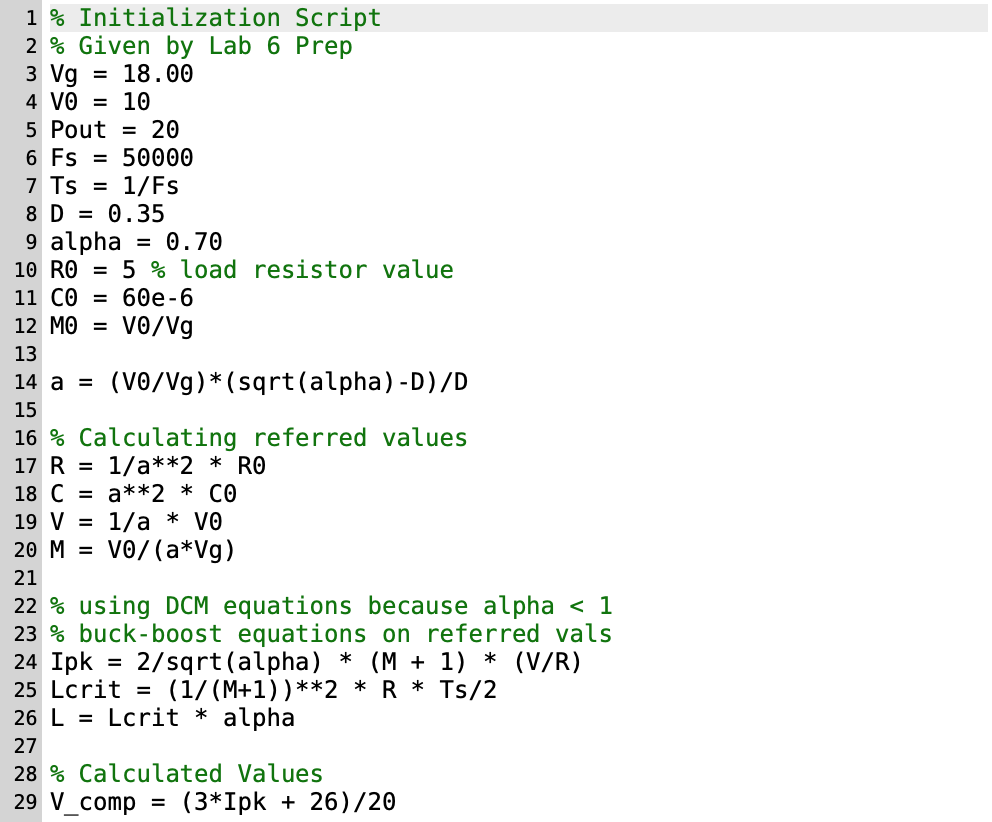

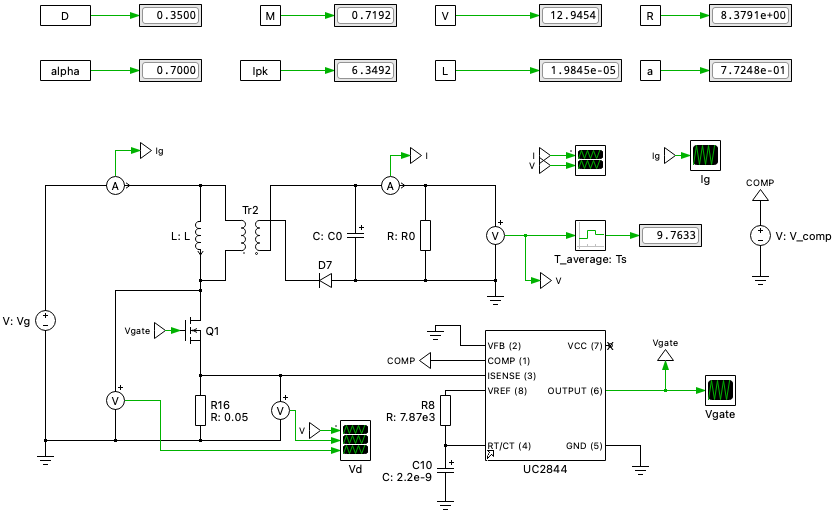

We can use the calculated `Ipk`, magnetizing inductance (`L`) and turns ratio (`a`) value to inform our transformer design. `L` and `Ipk` will allow us to define the minimum number of turns necessary to maintain a particular peak flux density, and `a` will define the turns ratio we create for the transformer. `Ipk` will also inform the appropriate wire gauge for our transformer.

In [160]:
import math
import numpy as np

# Given vals/requirements
B_MAX = 300e-3 # in T
A_RMS = 10 # in A_rms/mm^2
u_0 = 4*math.pi*1e-7 # permeability of free space in H/m
R_SH = 0.05
Vg = 18
D = 0.35

# Simulation results (see sim displays)
L = 1.94e-5 # in H
I_PK = 6.3492 # in A

Vo = 10
Pout = 20
Fs = 50000

A_MIN = 5.91e-5 # in m^2
phi_max = B_MAX * A_MIN
N_min = (L*I_PK)/phi_max 
print("Minimum number of turns for primary side: ", math.ceil(N_min))

Minimum number of turns for primary side:  7


In [109]:
awg_to_wire_diameter = { 18: 1.02, 20: 0.81, 22: 0.643, 24: 0.511 }
awg_to_wire_area = { 18: 0.823, 20: 0.518, 22: 0.326, 24: 0.205 }

ind_height = 14.30 # mm
I_rms = math.sqrt(D/3) * I_PK # Buck-Boost Converter I_RMS

print(f"Inductor Height: {ind_height} mm\n")

for awg, area in awg_to_wire_area.items():
    wire_diameter = awg_to_wire_diameter[awg]
    wire_space = wire_diameter + 0.2 # adding 0.2mm for insulation thickness
    max_turns = math.floor(ind_height / wire_space)
    
    J_max = I_rms / area
    
    print(f"{awg} AWG:")
    print(f"Max turns physically possible in space: {max_turns}")
    print(f"Current Density (J): {J_max:.2f} A_rms/mm^2\n")

Inductor Height: 14.3 mm

18 AWG:
Max turns physically possible in space: 11
Current Density (J): 2.64 A_rms/mm^2

20 AWG:
Max turns physically possible in space: 14
Current Density (J): 4.19 A_rms/mm^2

22 AWG:
Max turns physically possible in space: 16
Current Density (J): 6.65 A_rms/mm^2

24 AWG:
Max turns physically possible in space: 20
Current Density (J): 10.58 A_rms/mm^2



To achieve the maximal RMS current density in copper wire of 10 A_rms/mm^2, we needed to pick a wire gauge thicker than 24 AWG. We picked **22 AWG** because the calculated current density with the provided parameters comes out to ~6.65 A_rms/mm^2, well below 10, and because thinner wire is easier to wind than thicker wire (like 20 or 18 AWG). 

Using our N_min calculations from above, we knew that the minimum number of turns on the primary side would need to be **7** in order to achieve our maximum peak flux density requirement. Since we know from simulation that the desired turns ratio `a` should be 0.77248, we chose to recreate the ratio using a **7:9** (secondary:primary) turns ratio, since it's only about 0.005 away from the desired ratio and is made of small whole numbers.

$a = \frac{N_s}{N_p} = 0.77248 \approxeq 7/9$

The maximum number of turns we can theoretically pack into the bobbin on a single layer with a 0.2mm leeway given for insulation thickness and wire spacing was 16, so with a total of 7+9=16 turns we are just barely able to wind it in a single layer (although it is not imperative that it be in a single layer).

In [161]:
# Maxiumum Energy
W = (L*I_PK**2)/2 
print(f"Peak Energy: {W} J")

k = 0.8 # fill factor
N = 9  # number of turns on the primary side

# nominal values of outer and inner diameter of the winding
D_winding_outer = 18 # mm
D_winding_inner = 8.8 # mm
A_wind = math.pi * (D_winding_outer**2 - D_winding_inner**2)/4
print(f"Area of winding: {A_wind:.5g} mm^2")

F_max = J_max * k * A_wind

Peak Energy: 0.00039102970420799995 J
Area of winding: 193.65 mm^2


In [162]:
R_min = (2*W)/(phi_max**2) # minimum reluctance of the air gap
R_max = (F_max**2)/(2*W)

print(f"Minimum reluctance: {R_min:.3e}")
print(f"Maximum reluctance: {R_max:.3e}")
print(f"Range of l_eg: {(R_min*(u_0*A_MIN))/0.0254:.3g} in to {(R_max*(u_0*A_MIN))/0.0254:.3g} in")
print(f"Range of gap: {(R_min*(u_0*A_MIN))/(0.0254*2):.3g} in to {(R_max*(u_0*A_MIN))/(0.0254*2):.3g} in\n")

Minimum reluctance: 2.488e+06
Maximum reluctance: 3.434e+09
Range of l_eg: 0.00727 in to 10 in
Range of gap: 0.00364 in to 5.02 in



In [163]:
l_eg_in = 0.006*2 # inches (gap * 2)
l_eg = l_eg_in * 0.0254 # meters
R_e= l_eg/(u_0 * A_MIN) # reluctance of the air gap
L = N**2 * (1/R_e)

print(f"Reluctance of the air gap: {R_e:.3e}")
print(f"Inductance with air gap: {L*1e6:.3f} uH")

Reluctance of the air gap: 4.104e+06
Inductance with air gap: 19.736 uH


This calculation, driven by the minimum and maximum reluctance equations, gave us an approximate range of distances we could manually play around with to get an inductance value in range while still respecting the peak flux density constraint. After some experimentation, we got 0.006 inches between plates. While actually manufacturing the transformer, we experimented with different gap sizes near our calculated value and found that 0.007 inches gave us a near-perfect measured inductance value on the LCR. This distance was extremely close to the original calculated value, indicating minimal losses and near-ideal behavior!

### Helper Functions

In [190]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import find_peaks
pd.set_option('display.float_format', lambda x: '%e' % x)

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT

def plot_1ch_peaks(filepath, title, ch1label="Shunt Voltage (Vsh)", x1=None, x2=None): 
    data, t0, dT = read_rigol_csv("data/"+filepath+".csv")
    fig, ax = plt.subplots(figsize=(10, 6))
    data['CH1'] = data['CH1'].rolling(10, min_periods=1, center=True).mean()
    data.plot(x="X", y="CH1", ax=ax, label=ch1label, legend=False, color='tab:blue')

    peak_matrix = np.array([])
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        indices, _ = find_peaks(subset['CH1'], height=0, distance=50, prominence=0.1)
        
        peak_times = subset['X'].iloc[indices].values
        peak_values = subset['CH1'].iloc[indices].values
        peak_matrix = np.column_stack((peak_times, peak_values))
        
        ax.plot(peak_times, peak_values, ".", color="red", label='Peaks')

    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel(ch1label, fontsize=12)
    
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return peak_matrix

def plot_rigol(filepath, title, ch1label="Shunt Voltage (Vsh)", ch2label="Drain Voltage (Vd)", x1=None, x2=None): 
    data, t0, dT = read_rigol_csv("data/"+filepath+".csv")
    has_ch2 = 'CH2' in data.columns
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    data['CH1'] = data['CH1'].rolling(10, min_periods=1, center=True).mean()
    ax.plot(data['X'], data['CH1'], label=ch1label, color='tab:blue')
    ax.set_ylabel(ch1label, fontsize=12, color='tab:blue')
    
    ax2 = None
    if has_ch2:
        data['CH2'] = data['CH2'].rolling(10, min_periods=1, center=True).mean()
        ax2 = ax.twinx()  # Use twinx for cleaner secondary axis control
        ax2.plot(data['X'], data['CH2'], label=ch2label, color='tab:orange')
        ax2.set_ylabel(ch2label, fontsize=12, color='tab:orange')

    slope, ch2_mean = None, None
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        result = linregress(subset['X'], subset['CH1'])
        slope = result.slope
        fit = slope * subset['X'] + result.intercept
        ax.plot(subset['X'], fit, color="red", lw=3, ls=":", label='Linear Fit')
        
        if has_ch2:
            ch2_mean = subset['CH2'].mean()

    handles, labels = ax.get_legend_handles_labels()
    if ax2:
        h2, l2 = ax2.get_legend_handles_labels()
        handles += h2
        labels += l2
    if len(handles) > 1: # i dont want a legend when theres only one thing lol
        ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.02, 0.97), borderaxespad=0.)
    
    ax.set_xlabel("Time (s)", fontsize=12)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return (slope, ch2_mean) if has_ch2 else slope

### Q1-3

Input Current (4V): 0.29

Input Current (7V): 0.69

Input Current (10V): 1.28

Measured Output Voltage (4V): 4.08

Measured Output Voltage (7V): 6.99

Measured Output Voltage (10V): 9.99

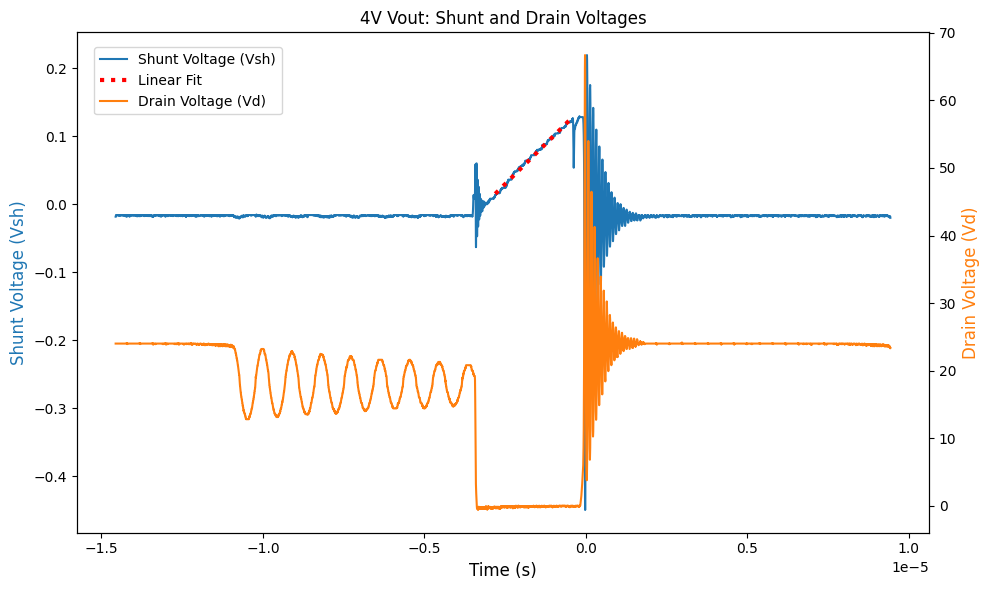

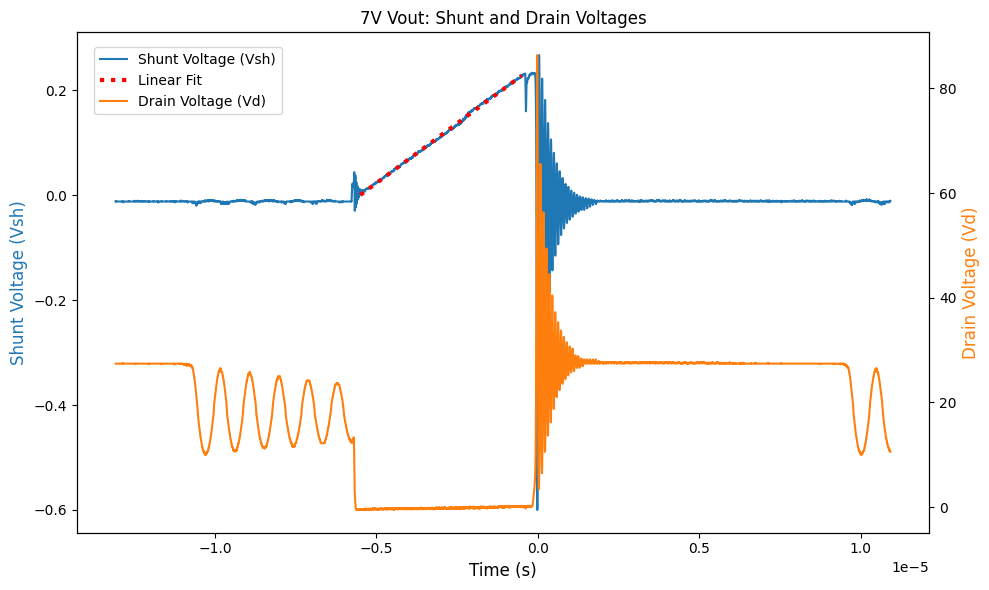

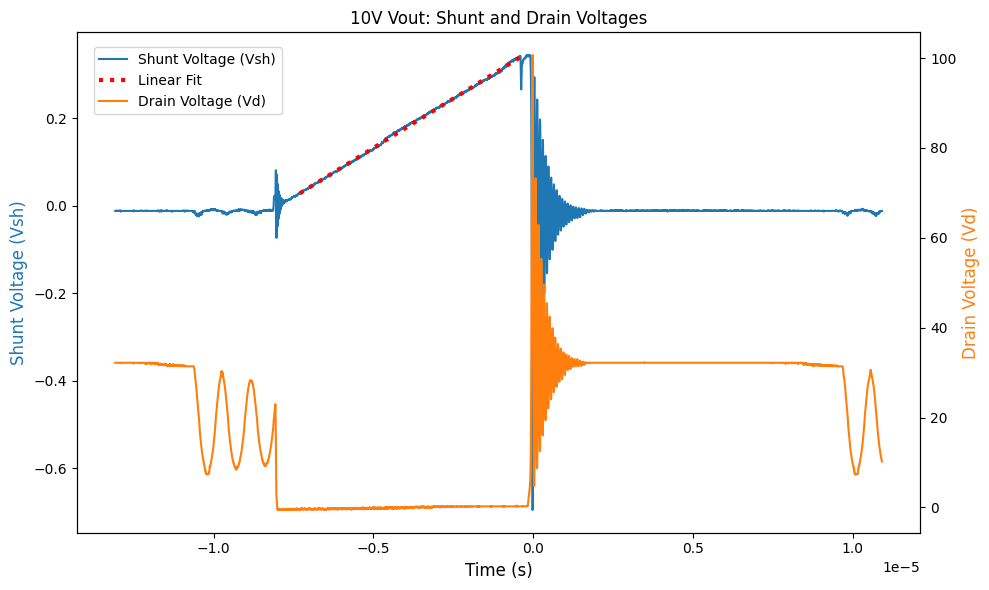

In [172]:
dvdt_4v, avg_vd_4v = plot_rigol("4vq1", "4V Vout: Shunt and Drain Voltages", x1=-2.8e-6, x2=-0.5e-6)
dvdt_7v, avg_vd_7v = plot_rigol("7vq1", "7V Vout: Shunt and Drain Voltages", x1=-5.5e-6, x2=-0.5e-6)
dvdt_10v, avg_vd_10v = plot_rigol("10vq1", "10V Vout: Shunt and Drain Voltages", x1=-7.3e-6, x2=-0.4e-6)

### Q6: Calculate the magnetizing inductance value of your transformer and verify the turns ratio from measurements

#### Magnetizing Inductance Calculation

In [167]:
test_scenarios = [
    (dvdt_4v, avg_vd_4v, "4V"),
    (dvdt_7v, avg_vd_7v, "7V"),
    (dvdt_10v, avg_vd_10v, "10V")
]
inductances = []

for slope, avg_vd, label in test_scenarios:
    Vind = Vg - avg_vd
    di_dt = slope / R_SH
    L = Vind / di_dt

    inductances.append(L)
    
    print(f"Results for {label}:")
    print(f"di/dt: {di_dt:.4f}A/s")
    print(f"The measured inductance value is {L*1e6:.4f}uH\n")

print(f"Our average calculated inductance is {np.mean(inductances)*1e6:.4f}uH")

Results for 4V:
di/dt: 941247.5808A/s
The measured inductance value is 19.2679uH

Results for 7V:
di/dt: 910487.2594A/s
The measured inductance value is 19.9941uH

Results for 10V:
di/dt: 900967.8265A/s
The measured inductance value is 19.9995uH

Our average calculated inductance is 19.7538uH


#### Turns Ratio Calculation
The appropriate turns ratio can be calculated from the following equation:

Vg = 18.00
V0 = 9.99
Pout = 20
Fs = 50000
Ts = 1/Fs
D = 0.35 # prove this using duty cycle claulcation
alpha = 0.70 # back calculate with ipk, get ipk from dividing peak of shunt voltage by shunt resistance
R0 = 5 % load resistor value
C0 = 60e-6
M0 = V0/Vg

a = (V0/Vg)*(sqrt(alpha)-D)/D ###### GET THIS AT THE END OF ALL YOUR ALGEBRA

% Calculating referred values
R = 1/a**2 * R0
C = a**2 * C0
V = 1/a * V0
M = V0/(a*Vg)

% using DCM equations because alpha < 1
% buck-boost equations on referred vals
Ipk = 2/sqrt(alpha) * (M + 1) * (V/R)
Lcrit = (1/(M+1))**2 * R * Ts/2
L = Lcrit * alpha

### Q7: Document adjustments made and experimental findings.
Our transformer met all requirements and thus did not require any adjustments! YAY!

### Q8: Analyze the potential causes for why the initial design did not meet the desired specifications.
N/A

### Q4, Q5, Q9: Plot the Vdrain ringing waveforms and calculate the damped natural frequency and damping ratio for each

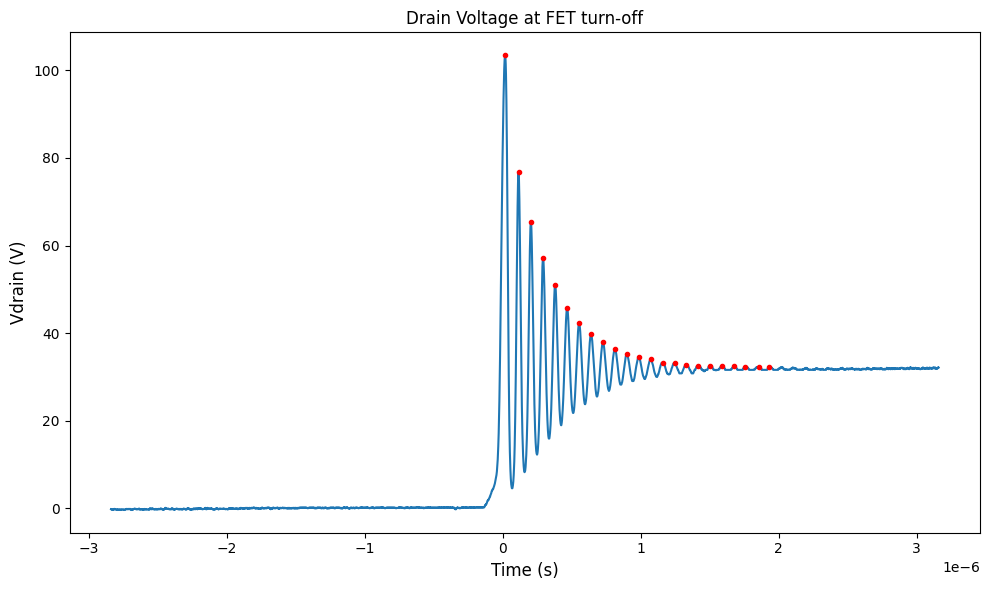

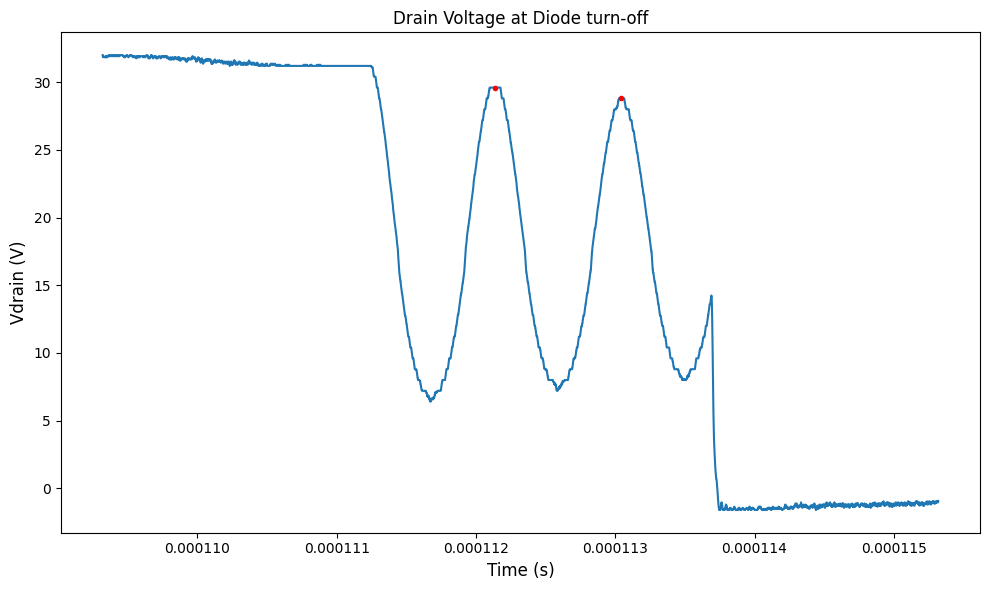

In [215]:
peaks_fetoff = plot_1ch_peaks("10vq4", "Drain Voltage at FET turn-off", "Vdrain (V)", x1=0, x2=2e-6)
peaks_diodeoff = plot_1ch_peaks("10vq5", "Drain Voltage at Diode turn-off", "Vdrain (V)", x1=0.000111, x2=0.0001135)

In [221]:
# FIND PEAKS 2pi/(difference in time between peaks)

def analyze_oscillations(peak_matrix):
    peak_matrix = np.asarray(peak_matrix)
    if peak_matrix.ndim < 2 or len(peak_matrix) < 2:
        return 0.0, 0.0

    times = peak_matrix[:, 0]
    peaks = peak_matrix[:, 1]

    avg_period = np.mean(np.diff(times))
    fd = 1.0 / avg_period

    x1 = peaks[0]
    xnp1 = peaks[-1]
    num_cycles = len(peaks) - 1

    # given by (1/n)*ln|x1/x_(n+1)|
    delta = np.log(x1 / xnp1) / num_cycles

    zeta = delta / np.sqrt(4 * np.pi**2 + delta**2)

    return fd, zeta

fn_fet, zeta_fet = analyze_oscillations(peaks_fetoff)
print(f"FET OFF: Damped Natural Frequency: {fn_fet:.2f} Hz, Damping Ratio: {zeta_fet:.4f}")
fn_diode, zeta_diode = analyze_oscillations(peaks_diodeoff)
print(f"DIODE OFF: Damped Natural Frequency: {fn_diode:.2f} Hz, Damping Ratio: {zeta_diode:.4f}")

FET OFF: Damped Natural Frequency: 11506276.15 Hz, Damping Ratio: 0.0084
DIODE OFF: Damped Natural Frequency: 1101321.59 Hz, Damping Ratio: 0.0044


### Q10: Based on the measurements, provide evidence that the electrical requirements of the flyback converter are met.
USE I_PK AND DUTY CYCLE FROM ACTUAL MEASUREMENTS

In [170]:
# ELECTRICAL
I_rms = math.sqrt(D/3) * I_PK # Buck-Boost Converter I_RMS
J_max = I_rms / awg_to_wire_area[22]
print(f"22 AWG Current Density (J): {J_max:.2f} A/mm^2\n")

22 AWG Current Density (J): 6.65 A/mm^2



### Q11: Based on the measurements, provide evidence that all of the transformer specifications are met.

In [88]:
# MINIMUM NUMBA OF TURNS (MAGNETIC) & CALCULATE ALPHA!!!
N_min = (L*I_PK)/phi_max
print("Minimum number of turns: ", math.ceil(N_min))

# ALPHA!!!! ALGEBRA!

Minimum number of turns:  8


### Transformer Drawing

### Independent Steps